# Day 4 — Feature Engineering & Hyperparameter Tuning

## Dataset: Census Ages 2017

This notebook applies the Day 4 requirements of Week 4:

- Feature Engineering
- Hyperparameter Selection
- GridSearchCV
- 5-Fold Stratified Cross-Validation
- Baseline vs Tuned Model Comparison
- Feature Importance Analysis

The goal is to use demographic information from the 2017 census
to predict the governorate of each locality.

## 1. Import Libraries

In this section, we import the Python libraries required for data
manipulation, model training, hyperparameter tuning, evaluation,
and visualization.

Pandas is used for working with the dataset, NumPy for numerical
operations, and Scikit-learn for machine learning.

Matplotlib is used to visualize feature importance.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

import matplotlib.pyplot as plt

## 2. Load the Dataset

The dataset contains demographic information from the 2017 census.

Each row represents a locality, while the columns contain population
counts for different age groups and genders.

The dataset will be used to build a classification model that predicts
the governorate associated with each locality.

In [2]:
df = pd.read_csv("census-ages-2017.csv")

df.head()

,Year,Governorate,Governorate_a,Locality,0_4_M,5_9_M,10_14_M,15_19_M,20_24_M,25_29_M,...,25_29_F,30_34_F,35_39_F,40_44_F,45_49_F,50_54_F,55_59_F,60_64_F,65P_F,Unknown_F
0,2017,Bethlehem,بيت لحم,الوَلَجَة,155,172,155,147,138,110,...,103,87,78,63,71,67,35,23,55,0
1,2017,Bethlehem,بيت لحم,بَتِّير,246,212,231,244,214,214,...,195,169,151,129,133,116,67,51,129,0
2,2017,Bethlehem,بيت لحم,العُبَيْدِيَّة,1236,989,790,827,797,667,...,573,423,345,305,272,212,142,86,171,0
3,2017,Bethlehem,بيت لحم,مُخَيَّمْ عايدَة,188,164,140,147,146,136,...,130,102,89,66,64,66,35,29,60,0
4,2017,Bethlehem,بيت لحم,خَلَّة النُعْمَان,1,6,6,6,7,4,...,1,5,4,6,2,2,4,5,0,0


## 3. Dataset Dimensions

Before building a model, it is important to understand the size of
the dataset.

The `shape` attribute returns the number of rows and columns.

The number of rows represents the number of localities, while the
number of columns represents the available variables.

In [3]:
df.shape

(586, 34)

## 4. Dataset Information

The `info()` method provides information about the dataset structure,
including:

- Column names
- Number of non-null values
- Data types
- Overall dataset size

This step helps us identify numeric and categorical variables before
feature engineering and model training.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           586 non-null    int64 
 1   Governorate    586 non-null    object
 2   Governorate_a  586 non-null    object
 3   Locality       586 non-null    object
 4   0_4_M          586 non-null    int64 
 5   5_9_M          586 non-null    int64 
 6   10_14_M        586 non-null    int64 
 7   15_19_M        586 non-null    int64 
 8   20_24_M        586 non-null    int64 
 9   25_29_M        586 non-null    int64 
 10  30_34_M        586 non-null    int64 
 11  35_39_M        586 non-null    int64 
 12  40_44_M        586 non-null    int64 
 13  45_49_M        586 non-null    int64 
 14  50_54_M        586 non-null    int64 
 15  55_59_M        586 non-null    int64 
 16  60_64_M        586 non-null    int64 
 17  65P_M          586 non-null    int64 
 18  Unknown_M      586 non-null   

## 5. Checking for Missing Values

Missing values can cause problems during model training.

Therefore, we check every column to determine whether any observations
are missing.

If missing values exist, they should be handled before training the
machine learning model.

In [5]:
df.isnull().sum()

Year             0
Governorate      0
Governorate_a    0
Locality         0
0_4_M            0
5_9_M            0
10_14_M          0
15_19_M          0
20_24_M          0
25_29_M          0
30_34_M          0
35_39_M          0
40_44_M          0
45_49_M          0
50_54_M          0
55_59_M          0
60_64_M          0
65P_M            0
Unknown_M        0
0_4_F            0
5_9_F            0
10_14_F          0
15_19_F          0
20_24_F          0
25_29_F          0
30_34_F          0
35_39_F          0
40_44_F          0
45_49_F          0
50_54_F          0
55_59_F          0
60_64_F          0
65P_F            0
Unknown_F        0
dtype: int64

## 6. Understanding the Target Variable

This is a classification problem.

The target variable is `Governorate`.

The model will learn patterns in the demographic structure of each
locality and use those patterns to predict its governorate.

Therefore:

- Features (X) = demographic population information
- Target (y) = Governorate

In [6]:
y = df["Governorate"].copy()

## 7. Selecting Appropriate Features

The dataset contains several columns related to location.

We should not use `Governorate_a` as a feature because it contains
the governorate name in another representation and would reveal the
target information directly.

`Locality` is also excluded because it is an identifier/name rather
than a demographic measurement.

`Year` is excluded because the dataset represents the 2017 census,
so it does not provide useful variation for prediction.

The model will therefore use demographic age and gender population
columns as input features.

## 8. Selecting Demographic Columns

The demographic variables are organized according to age groups and
gender.

Male population columns end with `_M`, while female population
columns end with `_F`.

We automatically identify these columns instead of manually writing
every column name.

In [7]:
male_cols = [col for col in df.columns if col.endswith("_M")]

female_cols = [col for col in df.columns if col.endswith("_F")]

age_cols = male_cols + female_cols

In [8]:
print("Male columns:", len(male_cols))
print("Female columns:", len(female_cols))
print("Total demographic features:", len(age_cols))

Male columns: 15
Female columns: 15
Total demographic features: 30


## 9. Creating the Feature Matrix

The feature matrix `X` contains only demographic information.

The target `y` contains the governorate labels.

Separating X and y is a standard step before splitting the data into
training and testing sets.

In [9]:
X = df[age_cols].copy()
y = df["Governorate"].copy()

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (586, 30)
y shape: (586,)


## 10. Feature Engineering

Feature engineering is the process of creating, transforming, or
selecting variables that provide more useful information to a machine
learning model.

For this dataset, the original variables contain population counts
for individual age and gender groups.

We will create additional demographic summary features that describe
the overall population structure.

The following engineered features will be created:

1. Total Population
2. Youth Ratio
3. Senior Ratio
4. Female Share

## 11. Engineered Feature 1 — Total Population

The original dataset contains separate population counts for many
age and gender groups.

We can combine these values into a single feature representing the
total population of each locality.

Formula:

Total Population = Sum of all demographic population groups

This feature provides the model with a direct measurement of the
overall population size of each locality.

In [11]:
X["total_population"] = X[age_cols].sum(axis=1)

In [12]:
X["total_population"].head()

0     2643
1     4646
2    14306
3     2794
4      111
Name: total_population, dtype: int64

## 12. Engineered Feature 2 — Youth Ratio

The youth ratio represents the proportion of people aged from 0 to 19
years within the total population.

Formula:

Youth Ratio = Population aged 0-19 / Total Population

This feature describes the demographic age structure of the locality.

Using a ratio instead of raw population counts can help the model
understand the relative composition of the population.

In [13]:
youth_cols = [
    "0_4_M", "5_9_M", "10_14_M", "15_19_M",
    "0_4_F", "5_9_F", "10_14_F", "15_19_F"
]

X["youth_ratio"] = (
    X[youth_cols].sum(axis=1) /
    X["total_population"]
)

In [14]:
X["youth_ratio"].head()

0    0.454030
1    0.411967
2    0.527541
3    0.440229
4    0.387387
Name: youth_ratio, dtype: float64

## 13. Engineered Feature 3 — Senior Ratio

The senior ratio represents the proportion of people aged 60 years
and above.

Formula:

Senior Ratio = Population aged 60+ / Total Population

This feature provides information about the age structure of the
locality and complements the youth ratio.

In [15]:
senior_cols = [
    "60_64_M", "65P_M",
    "60_64_F", "65P_F"
]

X["senior_ratio"] = (
    X[senior_cols].sum(axis=1) /
    X["total_population"]
)

In [16]:
X["senior_ratio"].head()

0    0.052592
1    0.073396
2    0.034531
3    0.055118
4    0.117117
Name: senior_ratio, dtype: float64

## 14. Engineered Feature 4 — Female Share

Female share represents the proportion of females within the total
population.

Formula:

Female Share = Female Population / Total Population

This feature summarizes the gender composition of each locality.

In [17]:
X["female_share"] = (
    X[female_cols].sum(axis=1) /
    X["total_population"]
)

In [18]:
X["female_share"].head()

0    0.485433
1    0.505381
2    0.486929
3    0.491768
4    0.531532
Name: female_share, dtype: float64

## 15. Checking the Engineered Features

After creating the new features, we inspect the dataset again.

This allows us to verify that the engineered variables were added
correctly and that their values are valid.

In [19]:
X.head()

,0_4_M,5_9_M,10_14_M,15_19_M,20_24_M,25_29_M,30_34_M,35_39_M,40_44_M,45_49_M,...,45_49_F,50_54_F,55_59_F,60_64_F,65P_F,Unknown_F,total_population,youth_ratio,senior_ratio,female_share
0,155,172,155,147,138,110,95,68,79,65,...,71,67,35,23,55,0,2643,0.454030,0.052592,0.485433
1,246,212,231,244,214,214,165,125,141,136,...,133,116,67,51,129,0,4646,0.411967,0.073396,0.505381
2,1236,989,790,827,797,667,506,362,333,295,...,272,212,142,86,171,0,14306,0.527541,0.034531,0.486929
3,188,164,140,147,146,136,98,83,70,72,...,64,66,35,29,60,0,2794,0.440229,0.055118,0.491768
4,1,6,6,6,7,4,3,2,3,2,...,2,2,4,5,0,0,111,0.387387,0.117117,0.531532


In [20]:
X.shape

(586, 34)

In [21]:
X.isnull().sum()

0_4_M               0
5_9_M               0
10_14_M             0
15_19_M             0
20_24_M             0
25_29_M             0
30_34_M             0
35_39_M             0
40_44_M             0
45_49_M             0
50_54_M             0
55_59_M             0
60_64_M             0
65P_M               0
Unknown_M           0
0_4_F               0
5_9_F               0
10_14_F             0
15_19_F             0
20_24_F             0
25_29_F             0
30_34_F             0
35_39_F             0
40_44_F             0
45_49_F             0
50_54_F             0
55_59_F             0
60_64_F             0
65P_F               0
Unknown_F           0
total_population    0
youth_ratio         0
senior_ratio        0
female_share        0
dtype: int64

## 16. Handling Invalid Values

Ratio-based features can potentially produce invalid values if the
total population is zero.

To make the feature matrix safe for model training, we replace
infinite values with missing values and then replace missing values
with zero.

This step ensures that the machine learning model receives valid
numeric values.

In [22]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

In [23]:
X.isnull().sum().sum()

np.int64(0)

## 17. Checking Class Distribution

Before training the classifier, we inspect how many observations
belong to each governorate.

This is important because classification performance can be affected
when some classes contain many more observations than others.

The result will also help explain why stratified splitting and
stratified cross-validation are useful.

In [24]:
y.value_counts()

Governorate
Hebron                   115
Jenin                     84
Ramallah and Al-Bireh     80
Nablus                    66
Bethlehem                 51
Tulkarm                   38
Qalqilia                  34
Jerusalem                 30
Tubas                     21
Salfit                    20
Jericho and Al Aghwar     14
Dier al Balah             11
Khan Yunis                 8
Gaza                       5
North Gaza                 5
Rafah                      4
Name: count, dtype: int64

## 18. Train-Test Split

The dataset is divided into two parts:

- Training set: used to train the model and perform hyperparameter tuning.
- Test set: held out for final evaluation.

The test set must not be used during hyperparameter tuning.

We use `stratify=y` so that the class distribution is preserved as
much as possible between the training and test sets.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 19. Baseline Random Forest

Before tuning the model, we need a baseline.

The baseline is an untuned Random Forest classifier using the default
model configuration apart from the fixed random state.

The baseline provides a reference point that will later be compared
with the tuned model.

This comparison allows us to determine whether hyperparameter tuning
actually improved the model.

In [26]:
baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 20. Baseline Predictions

After training the baseline Random Forest, we use it to predict the
governorates of the unseen test samples.

In [27]:
baseline_pred = baseline_model.predict(X_test)

## 21. Baseline Evaluation

We evaluate the baseline model using:

- Accuracy
- Weighted F1-score
- Classification Report

Accuracy measures the proportion of correct predictions.

Weighted F1-score is useful when the classes are not equally
represented because it accounts for the contribution of each class
according to its number of samples.

In [28]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="weighted"
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Weighted F1:", baseline_f1)

Baseline Accuracy: 0.3220338983050847
Baseline Weighted F1: 0.2787933138181757


## 22. Hyperparameter Tuning

A hyperparameter is a value selected before model training.

Examples for Random Forest include:

- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_split`: minimum number of samples required to split a node
- `min_samples_leaf`: minimum number of samples required in a leaf

Instead of choosing these values manually, we will use GridSearchCV
to systematically test multiple combinations.

## 23. Defining the Hyperparameter Grid

The parameter grid defines the values that GridSearchCV will test.

Each combination of these values represents a different Random Forest
configuration.

The goal is to find the combination that achieves the best
cross-validated weighted F1-score.

In [30]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

## 24. Stratified 5-Fold Cross-Validation

GridSearchCV needs a cross-validation strategy to evaluate each
hyperparameter combination.

We use StratifiedKFold with 5 folds.

Stratification attempts to preserve the class distribution in each
fold, which is particularly important for classification problems.

In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 25. Creating GridSearchCV

GridSearchCV will:

1. Generate all hyperparameter combinations.
2. Train a Random Forest for each combination.
3. Evaluate each configuration using 5-fold cross-validation.
4. Calculate the cross-validated score.
5. Select the best-performing configuration.

The scoring metric is weighted F1-score.

In [32]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

## 26. Running GridSearchCV

The following command starts the complete hyperparameter search.

The model is trained repeatedly using different hyperparameter
combinations and five-fold cross-validation.

The test set remains untouched during this process.

In [33]:
grid_search.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


## 27. Best Hyperparameters

After GridSearchCV finishes, we can retrieve the hyperparameter
combination that achieved the highest cross-validated weighted
F1-score.

These are the hyperparameters selected by the tuning process.

In [34]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


## 28. Best Cross-Validation Score

`best_score_` represents the mean cross-validated score achieved by
the best hyperparameter configuration during the GridSearch process.

This score is based on the training data and cross-validation folds,
not on the held-out test set.

In [35]:
print("Best Cross-Validation Weighted F1:")
print(grid_search.best_score_)

Best Cross-Validation Weighted F1:
0.30517887296527324


## 29. Getting the Best Model

`best_estimator_` returns the Random Forest configured with the
hyperparameters selected by GridSearchCV.

We will use this model for the final evaluation on the held-out
test set.

In [37]:
best_model = grid_search.best_estimator_

best_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 30. Tuned Model Predictions

The tuned model is now used to predict the test set.

The test set has not been used during the hyperparameter search, so
it can provide an unbiased final evaluation of the selected model.

In [38]:
tuned_pred = best_model.predict(X_test)

## 31. Tuned Model Evaluation

We calculate the same evaluation metrics used for the baseline:

- Accuracy
- Weighted F1-score
- Classification Report

Using the same metrics allows a fair comparison between the
untuned and tuned models.

In [39]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    average="weighted"
)

print("Tuned Accuracy:", tuned_accuracy)
print("Tuned Weighted F1:", tuned_f1)

Tuned Accuracy: 0.3220338983050847
Tuned Weighted F1: 0.2787933138181757


In [40]:
print(classification_report(y_test, tuned_pred))

                       precision    recall  f1-score   support

            Bethlehem       0.33      0.20      0.25        10
        Dier al Balah       0.50      0.50      0.50         2
                 Gaza       0.00      0.00      0.00         1
               Hebron       0.44      0.70      0.54        23
                Jenin       0.07      0.06      0.06        17
Jericho and Al Aghwar       0.00      0.00      0.00         3
            Jerusalem       0.67      0.67      0.67         6
           Khan Yunis       0.00      0.00      0.00         2
               Nablus       0.33      0.31      0.32        13
           North Gaza       0.00      0.00      0.00         1
             Qalqilia       0.00      0.00      0.00         7
                Rafah       0.00      0.00      0.00         1
Ramallah and Al-Bireh       0.29      0.50      0.36        16
               Salfit       0.00      0.00      0.00         4
                Tubas       0.00      0.00      0.00  

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 32. Baseline vs Tuned Model

The main purpose of hyperparameter tuning is to determine whether
a better configuration improves the model.

We compare the baseline Random Forest with the tuned Random Forest
using the same held-out test set.

This provides a direct measurement of the effect of hyperparameter
tuning.

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ],
    "Weighted F1": [
        baseline_f1,
        tuned_f1
    ]
})

comparison

,Model,Accuracy,Weighted F1
0,Baseline Random Forest,0.322034,0.278793
1,Tuned Random Forest,0.322034,0.278793


## 33. Measuring Improvement

To understand the effect of tuning more clearly, we calculate the
change in Accuracy and Weighted F1-score.

A positive value indicates an improvement over the baseline.

In [42]:
accuracy_improvement = tuned_accuracy - baseline_accuracy
f1_improvement = tuned_f1 - baseline_f1

print("Accuracy Improvement:", accuracy_improvement)
print("Weighted F1 Improvement:", f1_improvement)

Accuracy Improvement: 0.0
Weighted F1 Improvement: 0.0


## 34. Feature Importance

Random Forest provides feature importance values that indicate how
strongly each feature contributed to the model's decisions.

We examine the most important features and check whether any of the
engineered features contributed significantly to the final model.

This helps us evaluate the practical value of our feature engineering.

In [44]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

## 35. Top 15 Features

The following table shows the fifteen features with the highest
importance values according to the tuned Random Forest.

In [45]:
feature_importance.head(15)

youth_ratio     0.076567
senior_ratio    0.057137
female_share    0.044162
0_4_M           0.032852
55_59_F         0.031690
0_4_F           0.030315
60_64_M         0.030029
65P_F           0.029687
15_19_F         0.029622
45_49_M         0.029498
55_59_M         0.029012
50_54_F         0.028756
5_9_M           0.027850
35_39_M         0.027798
50_54_M         0.027725
dtype: float64

## 36. Visualizing Feature Importance

A horizontal bar chart makes it easier to compare the contribution
of the most important features.

The visualization helps identify whether the engineered demographic
features appear among the strongest predictors.

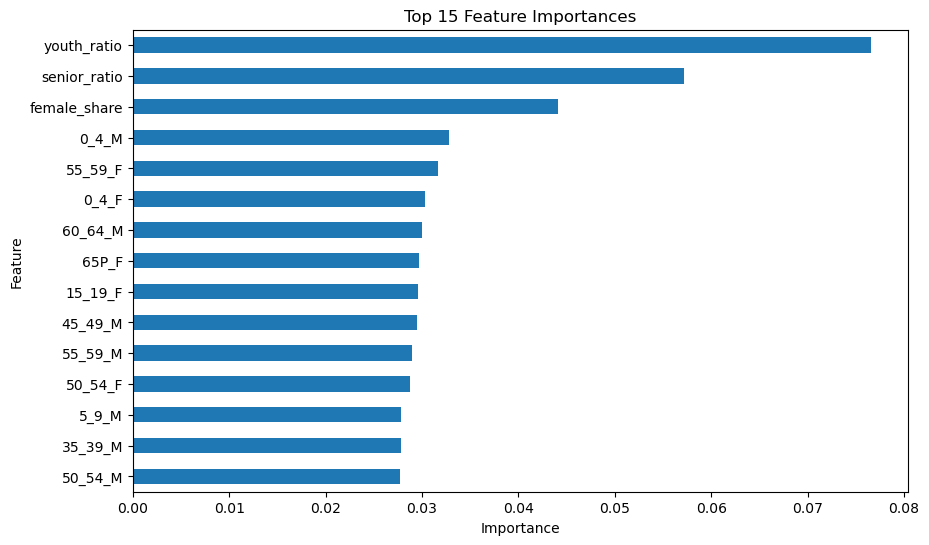

In [46]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 37. Engineered Feature Analysis

The engineered features created in this notebook are:

- `total_population`
- `youth_ratio`
- `senior_ratio`
- `female_share`

We now inspect their importance and determine whether they contributed
meaningfully to the final model.

In [47]:
engineered_features = [
    "total_population",
    "youth_ratio",
    "senior_ratio",
    "female_share"
]

feature_importance[
    feature_importance.index.isin(engineered_features)
]

youth_ratio         0.076567
senior_ratio        0.057137
female_share        0.044162
total_population    0.025371
dtype: float64

## 38. Most Important Engineered Feature

The engineered feature with the highest feature importance can be
identified from the previous result.

This allows us to answer one of the Day 4 requirements:

Which engineered feature mattered most?

The conclusion should be based on the actual feature importance
values rather than assumptions.

In [48]:
most_important_engineered_feature = (
    feature_importance[
        feature_importance.index.isin(engineered_features)
    ].idxmax()
)

most_important_engineered_feature

'youth_ratio'

In [49]:
feature_importance[most_important_engineered_feature]

np.float64(0.07656734973734002)

## 39. Inspecting GridSearchCV Results

GridSearchCV stores the results of every hyperparameter combination
in `cv_results_`.

We convert these results into a DataFrame so that the different
configurations can be compared and analyzed.

In [50]:
results = pd.DataFrame(
    grid_search.cv_results_
)

## 40. Top Hyperparameter Configurations

The following table displays the best-performing hyperparameter
combinations according to their mean cross-validated weighted
F1-score.

In [51]:
results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score
0,100,None,2,1,0.305179,0.041077
16,100,20,2,1,0.304554,0.041647
9,200,10,2,1,0.300220,0.034522
17,200,20,2,1,0.295398,0.044056
1,200,None,2,1,0.295019,0.043676
15,200,10,5,2,0.286981,0.026258
13,200,10,2,2,0.286194,0.038873
22,100,20,5,2,0.284707,0.051445
6,100,None,5,2,0.284447,0.051662
18,100,20,5,1,0.281898,0.031657


## 41. Hyperparameter Analysis

The GridSearchCV results show which combination of hyperparameters
performed best during cross-validation.

The final report should mention the selected values for:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required for splitting (`min_samples_split`)
- Minimum samples allowed in a leaf (`min_samples_leaf`)

The analysis should be based on the actual GridSearchCV results.